PART 04: FEATURE MAP COMPLEXITY STUDY

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml

print("pennylane version:", qml.__version__)

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

pennylane version: 0.38.0


2-qubit 1 layer

[[1.         0.98016591 0.90998223 0.89189284 0.68328216 0.66943593
  0.51292058 0.49775079]
 [0.98016591 1.         0.89189284 0.90998223 0.66943593 0.68328216
  0.49775079 0.51292058]
 [0.90998223 0.89189284 1.         0.98016591 0.41138815 0.40316311
  0.23404969 0.22729811]
 [0.89189284 0.90998223 0.98016591 1.         0.40316311 0.41138815
  0.22729811 0.23404969]
 [0.68328216 0.66943593 0.41138815 0.40316311 1.         0.98016591
  0.95001624 0.92170878]
 [0.66943593 0.68328216 0.40316311 0.41138815 0.98016591 1.
  0.92170878 0.95001624]
 [0.51292058 0.49775079 0.23404969 0.22729811 0.95001624 0.92170878
  1.         0.9558352 ]
 [0.49775079 0.51292058 0.22729811 0.23404969 0.92170878 0.95001624
  0.9558352  1.        ]]
Diagonal: [1. 1. 1. 1. 1. 1. 1. 1.]
Symmetry: True


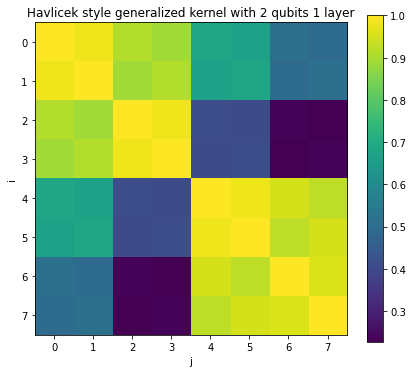

In [4]:
#device
n_qubits = 2
dev = qml.device('default.qubit', wires=n_qubits)

#circuit
def phi_single(x_i):
    return 2 * x_i

def phi_pair(x_i, x_j):
    return 2 * (np.pi - x_i) * (np.pi - x_j)

def havlicek_feature_map_general(x):
    n = len(x)
    for i in range(n):
        #Hadamard gate on every qubit
        qml.Hadamard(wires=i)
    
    for i in range(n):
        #single qubit phase terms
        qml.RZ(phi_single(x[i]), wires = i)
           
    #pairwize ZZ interaction terms
    for i in range(n):
        for j in range(i + 1, n):
            qml.CNOT(wires=[i,j])
            qml.RZ(phi_pair(x[i], x[j]), wires=j)
            qml.CNOT(wires=[i,j])

#Sample dataset
X = np.array([
    [0.1, 0.2],
    [0.2, 0.1],
    [0.15, 0.25],
    [0.25, 0.15],
    [1.8, 1.9],
    [1.9, 1.8],
    [1.7, 1.85],
    [1.85, 1.7]
])

y = np.array([0, 0, 0, 0, 1, 1, 1, 1])

#kernel circuit general
@qml.qnode(dev)
def kernel_circuit_general(x1, x2):
    havlicek_feature_map_general(x1)
    qml.adjoint(havlicek_feature_map_general)(x2)
    return qml.probs(wires=range(n_qubits))

#kernel value
def kernel_general(x1, x2):
    return kernel_circuit_general(x1, x2)[0]

#kernel matrix
def kernel_matrix_general(A, B):
    K = np.zeros((len(A), len(B)))
    for i in range(len(A)):
        for j in range(len(B)):
            K[i,j] = kernel_general(A[i], B[j])
    return K

K = kernel_matrix_general(X, X)
print(K)
print("Diagonal:", np.diag(K))
print("Symmetry:", np.allclose(K, K.T))

#plot
plt.figure(figsize=(7,6))
plt.imshow(K)
plt.colorbar()
plt.title("Havlicek style generalized kernel with 2 qubits 1 layer")
plt.xlabel("j")
plt.ylabel("i")
plt.show()

3-qubit 1 layer

[[1.         0.66256486 0.86884905 0.01786255 0.04233855 0.01325933]
 [0.66256486 1.         0.70688094 0.01613487 0.03265908 0.00760386]
 [0.86884905 0.70688094 1.         0.00865862 0.03842361 0.00498491]
 [0.01786255 0.01613487 0.00865862 1.         0.79062777 0.93770169]
 [0.04233855 0.03265908 0.03842361 0.79062777 1.         0.77497331]
 [0.01325933 0.00760386 0.00498491 0.93770169 0.77497331 1.        ]]
Diagonal: [1. 1. 1. 1. 1. 1.]
Symmetry: True


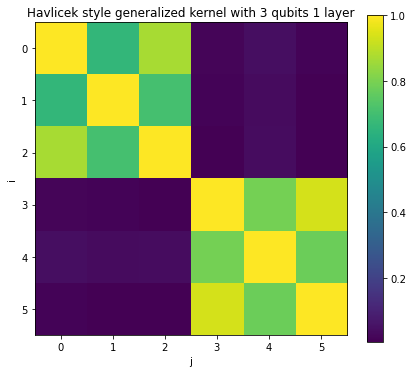

In [5]:
#device
n_qubits = 3
dev = qml.device('default.qubit', wires=n_qubits)

#circuit
def phi_single(x_i):
    return 2 * x_i

def phi_pair(x_i, x_j):
    return 2 * (np.pi - x_i) * (np.pi - x_j)

def havlicek_feature_map_general(x):
    n = len(x)
    for i in range(n):
        #Hadamard gate on every qubit
        qml.Hadamard(wires=i)
    
    for i in range(n):
        #single qubit phase terms
        qml.RZ(phi_single(x[i]), wires = i)
           
    #pairwize ZZ interaction terms
    for i in range(n):
        for j in range(i + 1, n):
            qml.CNOT(wires=[i,j])
            qml.RZ(phi_pair(x[i], x[j]), wires=j)
            qml.CNOT(wires=[i,j])

#Sample data
X = np.array([
    [0.1, 0.2, 0.1],
    [0.2, 0.1, 0.2],
    [0.15, 0.25, 0.1],
    [1.8, 1.9, 1.7],
    [1.9, 1.8, 1.9],
    [1.7, 1.85, 1.8]
])

y = np.array([0, 0, 0, 1, 1, 1])

#kernel circuit general
@qml.qnode(dev)
def kernel_circuit_general(x1, x2):
    havlicek_feature_map_general(x1)
    qml.adjoint(havlicek_feature_map_general)(x2)
    return qml.probs(wires=range(n_qubits))

#kernel value
def kernel_general(x1, x2):
    return kernel_circuit_general(x1, x2)[0]

#kernel matrix
def kernel_matrix_general(A, B):
    K = np.zeros((len(A), len(B)))
    for i in range(len(A)):
        for j in range(len(B)):
            K[i,j] = kernel_general(A[i], B[j])
    return K

K = kernel_matrix_general(X, X)
print(K)
print("Diagonal:", np.diag(K))
print("Symmetry:", np.allclose(K, K.T))

#plot
plt.figure(figsize=(7,6))
plt.imshow(K)
plt.colorbar()
plt.title("Havlicek style generalized kernel with 3 qubits 1 layer")
plt.xlabel("j")
plt.ylabel("i")
plt.show()

Note: After increasing qubit number kernel looks more structured, state similarity increased also the difference.

3-qubit 3 layers

[[1.         0.51486927 0.68279111 0.24279663 0.01330515 0.35414837]
 [0.51486927 1.         0.82298196 0.40372636 0.09433878 0.47499102]
 [0.68279111 0.82298196 1.         0.4212478  0.12771485 0.49991718]
 [0.24279663 0.40372636 0.4212478  1.         0.49786657 0.86452726]
 [0.01330515 0.09433878 0.12771485 0.49786657 1.         0.4278048 ]
 [0.35414837 0.47499102 0.49991718 0.86452726 0.4278048  1.        ]]
Diagonals: [1. 1. 1. 1. 1. 1.]
Symmetry: True


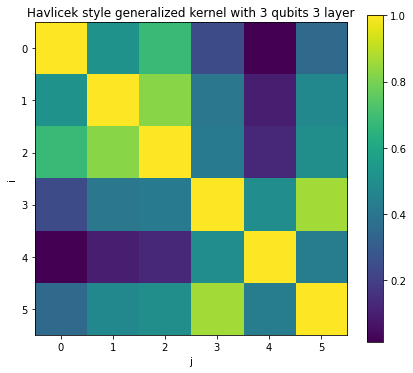

In [6]:
#adding layers
def havlicek_feature_map_general_layered(x, layers=3):
    n = len(x)
    
    for _ in range(layers):
        for i in range(n):
            qml.Hadamard(wires=i)
        for i in range(n):
            qml.RZ(phi_single(x[i]), wires=i)
        for i in range(n):
            for j in range(i+1, n):
                qml.CNOT(wires=[i, j])
                qml.RZ(phi_pair(x[i], x[j]), wires=j)
                qml.CNOT(wires=[i, j])
#circuit
@qml.qnode(dev)
def kernel_circuit_general_layered(x1, x2):
    havlicek_feature_map_general_layered(x1)
    qml.adjoint(havlicek_feature_map_general_layered)(x2)
    return qml.probs(wires=range(n_qubits))

#kernel value
def kernel_general_layered(x1, x2):
    return kernel_circuit_general_layered(x1, x2)[0]

#kernel matrix
def kernel_matrix_general_layered(A, B):
    K = np.zeros((len(A), len(B)))
    for i in range(len(A)):
        for j in range(len(B)):
            K[i,j] = kernel_general_layered(A[i], B[j])
    return K
K = kernel_matrix_general_layered(X, X)
print(K)
print("Diagonals:", np.diag(K))
print("Symmetry:", np.allclose(K, K.T))

#plot
plt.figure(figsize=(7,6))
plt.imshow(K)
plt.colorbar()
plt.xlabel("j")
plt.ylabel("i")
plt.title("Havlicek style generalized kernel with 3 qubits 3 layer")
plt.show()

3-qubit 5 layers

[[1.00000000e+00 4.96536912e-01 4.60413286e-01 1.13486467e-02
  2.43685688e-04 7.85861575e-03]
 [4.96536912e-01 1.00000000e+00 9.33769121e-01 7.11868548e-02
  8.16460662e-02 2.75566914e-02]
 [4.60413286e-01 9.33769121e-01 1.00000000e+00 1.05398547e-01
  5.27670987e-02 3.86118473e-02]
 [1.13486467e-02 7.11868548e-02 1.05398547e-01 1.00000000e+00
  2.58372256e-01 9.17846981e-01]
 [2.43685688e-04 8.16460662e-02 5.27670987e-02 2.58372256e-01
  1.00000000e+00 2.14975746e-01]
 [7.85861575e-03 2.75566914e-02 3.86118473e-02 9.17846981e-01
  2.14975746e-01 1.00000000e+00]]
Diagonals: [1. 1. 1. 1. 1. 1.]
Symmetry: True


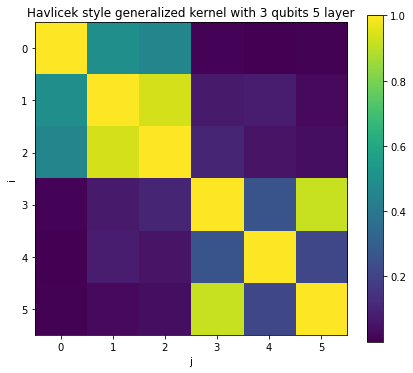

In [7]:
#adding layers
def havlicek_feature_map_general_layered(x, layers=5):
    n = len(x)
    
    for _ in range(layers):
        for i in range(n):
            qml.Hadamard(wires=i)
        for i in range(n):
            qml.RZ(phi_single(x[i]), wires=i)
        for i in range(n):
            for j in range(i+1, n):
                qml.CNOT(wires=[i, j])
                qml.RZ(phi_pair(x[i], x[j]), wires=j)
                qml.CNOT(wires=[i, j])
#circuit
@qml.qnode(dev)
def kernel_circuit_general_layered(x1, x2):
    havlicek_feature_map_general_layered(x1)
    qml.adjoint(havlicek_feature_map_general_layered)(x2)
    return qml.probs(wires=range(n_qubits))

#kernel value
def kernel_general_layered(x1, x2):
    return kernel_circuit_general_layered(x1, x2)[0]

#kernel matrix
def kernel_matrix_general_layered(A, B):
    K = np.zeros((len(A), len(B)))
    for i in range(len(A)):
        for j in range(len(B)):
            K[i,j] = kernel_general_layered(A[i], B[j])
    return K
K = kernel_matrix_general_layered(X, X)
print(K)
print("Diagonals:", np.diag(K))
print("Symmetry:", np.allclose(K, K.T))

#plot
plt.figure(figsize=(7,6))
plt.imshow(K)
plt.colorbar()
plt.xlabel("j")
plt.ylabel("i")
plt.title("Havlicek style generalized kernel with 3 qubits 5 layer")
plt.show()

      Map       |      Observation
----------------------------------------
2-qubit 1-layer |   simple map
3-qubit 1-layer |   more distinctive structure
3-qubit 3-layer |   more expressive kernel
3-qubit 5-layer |   flatter/partually wached out kernel


Note: Increasing the number of qubits enriched the kernel structure by introducing more interaction terms. Increasing the number of layers initially made the kernel more expressive, but at larger depth the kernel became flatter again, suggesting that excessive feature-map complexity may wash out useful structure rather than improve it.

Conclusion: Deeper circuits doesn't mean better mapping.

END OF THE REPO